In [57]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline


In [3]:
"""
AdaptiveForecaster - A flexible class for time series forecasting with sktime
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Union, Dict, Any, Optional, Tuple

from sktime.forecasting.model_selection import (
    ForecastingGridSearchCV, 
    temporal_train_test_split
)
from sktime.split import (
    ExpandingWindowSplitter, 
    SlidingWindowSplitter,
    TemporalTrainTestSplitter
)
from sktime.performance_metrics.forecasting import (
    MeanAbsolutePercentageError, 
    MeanSquaredError,
    MeanAbsoluteError
)

# Import our models factory
from models import get_forecaster, ALGORITHM_MAP

class AdaptiveForecaster:
    """
    A flexible class for time series forecasting that allows users to:
    - Choose from various forecasting algorithms
    - Apply different cross-validation strategies
    - Select performance metrics
    - Fit, predict and evaluate models
    - Visualize results
    
    This class wraps around the forecaster factory in models.py
    """
    
    def __init__(
        self,
        algorithm: str = 'arima',
        seasonal_period: int = 12,
        fh: Union[int, List[int]] = 3,
        cv_strategy: str = 'expanding',
        cv_window_length: int = 12,
        cv_step_length: int = 1,
        cv_initial_window: int = 24,
        test_size: float = 0.2,
        metric: str = 'rmse',
        n_jobs: int = -1,
        verbose: int = 1
    ):
        """
        Initialize the AdaptiveForecaster.
        
        Parameters
        ----------
        algorithm : str, default='arima'
            Name of the forecasting algorithm to use. Must be a key in ALGORITHM_MAP.
        seasonal_period : int, default=12
            The seasonal period of the time series.
        fh : int or list of ints, default=3
            The forecast horizon.
        cv_strategy : str, default='expanding'
            The cross-validation strategy to use. 
            Options: 'expanding', 'sliding', 'temporal'.
        cv_window_length : int, default=12
            The length of the window for cross-validation.
        cv_step_length : int, default=1
            The step length for sliding and expanding window cross-validation.
        cv_initial_window : int, default=24
            The initial window size for expanding window cross-validation.
        test_size : float, default=0.2
            The proportion of the dataset to include in the test split when using
            temporal_train_test_split.
        metric : str, default='rmse'
            The performance metric to use. 
            Options: 'rmse', 'mse', 'mae', 'mape'.
        n_jobs : int, default=-1
            The number of jobs to run in parallel.
        verbose : int, default=1
            The verbosity level.
        """
        # Validate algorithm
        if algorithm not in ALGORITHM_MAP:
            raise ValueError(f"Unknown algorithm: {algorithm}. Available: {list(ALGORITHM_MAP.keys())}")
        
        self.algorithm = algorithm
        self.seasonal_period = seasonal_period
        self.fh = fh
        self.cv_strategy = cv_strategy
        self.cv_window_length = cv_window_length
        self.cv_step_length = cv_step_length
        self.cv_initial_window = cv_initial_window
        self.test_size = test_size
        self.metric_name = metric
        self.n_jobs = n_jobs
        self.verbose = verbose
        
        # Initialize attributes that will be set later
        self.forecaster = None
        self.cv_splitter = None
        self.grid_search = None
        self.best_params = None
        self.best_score = None
        self.predictions = None
        self.prediction_intervals = None
        self.train_y = None
        self.test_y = None
        self.metric_func = None
        self.test_score = None
        
        # Set up the forecaster and cross-validation
        self._setup_forecaster()
        self._setup_metric()
    
    def _setup_forecaster(self):
        """Set up the forecaster using models.py factory function."""
        self.forecaster = get_forecaster(
            algorithm=self.algorithm,
            seasonal_period=self.seasonal_period
        )
    
    def _setup_metric(self):
        """Set up the performance metric function."""
        self.metrics_map = {
            'rmse': MeanSquaredError(square_root=True),
            'mse': MeanSquaredError(square_root=False),
            'mae': MeanAbsoluteError(),
            'mape': MeanAbsolutePercentageError()
        }
        
        if self.metric_name not in self.metrics_map:
            raise ValueError(f"Unknown metric: {self.metric_name}. Available: {list(self.metrics_map.keys())}")
        
        self.metric_func = self.metrics_map[self.metric_name]
    
    def _setup_cv_splitter(self, y=None):
        """Set up the cross-validation splitter based on cv_strategy."""
        if self.cv_strategy == 'expanding':
            self.cv_splitter = ExpandingWindowSplitter(
                initial_window=self.cv_initial_window,
                step_length=self.cv_step_length,
                fh=self.fh
            )
        elif self.cv_strategy == 'sliding':
            self.cv_splitter = SlidingWindowSplitter(
                window_length=self.cv_window_length,
                step_length=self.cv_step_length,
                fh=self.fh
            )
        elif self.cv_strategy == 'temporal':
            if y is None:
                raise ValueError("For temporal CV, y must be provided at initialization")
            self.cv_splitter = TemporalTrainTestSplitter(
                test_size=self.test_size
            )
        else:
            raise ValueError(f"Unknown CV strategy: {self.cv_strategy}. "
                             f"Available: ['expanding', 'sliding', 'temporal']")
    
    def setup_grid_search(self, y=None, param_grid=None):
        """
        Set up the grid search cross-validation.
        
        Parameters
        ----------
        y : pd.Series, optional
            The time series data. Required for temporal CV.
        param_grid : dict, optional
            The parameter grid for grid search. If None, uses the default from the forecaster.
        """
        self._setup_cv_splitter(y)
        
        if param_grid is None:
            param_grid = self.forecaster.get_param_grid()
        
        self.grid_search = ForecastingGridSearchCV(
            forecaster=self.forecaster.permuted,
            param_grid=param_grid,
            cv=self.cv_splitter,
            scoring=self.metric_func,
            n_jobs=self.n_jobs,
            verbose=self.verbose
        )
        
        return self
    
    def split_data(self, y, test_size=None):
        """
        Split the data into training and test sets.
        
        Parameters
        ----------
        y : pd.Series
            The time series data.
        test_size : float, optional
            The proportion of the dataset to include in the test split.
            If None, uses the value from initialization.
        
        Returns
        -------
        train_y, test_y : pd.Series
            The training and test data.
        """
        if test_size is None:
            test_size = self.test_size
        
        self.train_y, self.test_y = temporal_train_test_split(y, test_size=test_size)
        return self.train_y, self.test_y
    
    def fit(self, y, X=None, fh=None, use_test_set=False):
        """
        Fit the forecaster to the training data.
        
        Parameters
        ----------
        y : pd.Series
            The time series data.
        X : pd.DataFrame, optional
            Exogenous variables.
        fh : int or list of ints, optional
            The forecast horizon. If None, uses the value from initialization.
        use_test_set : bool, default=False
            Whether to split the data into train/test sets for final evaluation.
            If True, y is split internally and only the training portion is used for fitting.
        
        Returns
        -------
        self : AdaptiveForecaster
            The fitted forecaster.
        """
        if fh is not None:
            self.fh = fh
        
        # Handle train/test split if requested
        if use_test_set and self.train_y is None:
            print("Splitting data into train/test sets...")
            self.train_y, self.test_y = self.split_data(y)
            # Use training data for fitting
            y_to_fit = self.train_y
        else:
            # Use all data for fitting
            y_to_fit = y
        
        if self.grid_search is None:
            self.setup_grid_search(y_to_fit)
        
        print(f"Fitting {self.algorithm} forecaster with {self.cv_strategy} cross-validation...")
        self.grid_search.fit(y_to_fit, X=X, fh=self.fh)
        
        self.best_params = self.grid_search.best_params_
        self.best_score = self.grid_search.best_score_
        
        return self
    
    def predict(self, fh=None, X=None, return_pred_int=False, coverage=[0.95]):
        """
        Make predictions with the fitted forecaster.
        
        Parameters
        ----------
        fh : int or list of ints, optional
            The forecast horizon. If None, uses the value from initialization.
        X : pd.DataFrame, optional
            Exogenous variables.
        return_pred_int : bool, default=False
            Whether to return prediction intervals.
        coverage : list of float, default=[0.95]
            The coverage of prediction intervals.
        
        Returns
        -------
        predictions : pd.Series
            The point forecasts.
        """
        if self.grid_search is None or not hasattr(self.grid_search, 'best_forecaster_'):
            raise ValueError("Forecaster has not been fitted yet. Call fit() first.")
        
        if fh is None:
            fh = self.fh
        
        print("Making predictions...")
        self.predictions = self.grid_search.best_forecaster_.predict(fh, X=X)
        
        if return_pred_int:
            try:
                self.prediction_intervals = self.grid_search.best_forecaster_.predict_interval(
                    fh=list(range(1, fh + 1)), X=X, coverage=coverage
                )
            except Exception as e:
                print(f"Warning: Could not compute prediction intervals: {e}")
                self.prediction_intervals = None
        
        return self.predictions
    
    def evaluate(self, y_true=None, in_sample=False, metrics=None):
        """
        Evaluate the forecaster on test data or in-sample using multiple metrics.
        
        Parameters
        ----------
        y_true : pd.Series, optional
            The true values to compare against. If None, uses self.test_y or the training data.
        in_sample : bool, default=False
            Whether to evaluate on the training data (in-sample) instead of test data.
            If True and y_true is None, will use the training data.
        metrics : list of str, optional
            List of metric names to compute. If None, computes all available metrics.
            Available: 'rmse', 'mse', 'mae', 'mape'
        
        Returns
        -------
        scores : dict
            Dictionary with metric names as keys and scores as values.
        """
        if self.predictions is None:
            raise ValueError("No predictions available. Call predict() first.")
        
        if y_true is None:
            if in_sample:
                if self.train_y is not None:
                    y_true = self.train_y
                else:
                    raise ValueError("No training data available. Provide y_true or call split_data() first.")
            else:
                if self.test_y is not None:
                    y_true = self.test_y
                else:
                    raise ValueError("No test data available. Provide y_true, call split_data(), "
                                   "or set in_sample=True to evaluate on training data.")
        
        # Align indices for evaluation
        # Only use the indices that appear in both series
        common_indices = y_true.index.intersection(self.predictions.index)
        if len(common_indices) == 0:
            raise ValueError("No common indices between true values and predictions")
        
        y_true_aligned = y_true.loc[common_indices]
        predictions_aligned = self.predictions.loc[common_indices]
        
        # Determine which metrics to compute
        if metrics is None:
            metrics_to_compute = list(self.metrics_map.keys())
        else:
            invalid_metrics = [m for m in metrics if m not in self.metrics_map]
            if invalid_metrics:
                raise ValueError(f"Unknown metrics: {invalid_metrics}. Available: {list(self.metrics_map.keys())}")
            metrics_to_compute = metrics
        
        # Compute all requested metrics
        scores = {}
        for metric_name in metrics_to_compute:
            metric_func = self.metrics_map[metric_name]
            scores[metric_name] = metric_func(y_true_aligned, predictions_aligned)
        
        # Store the main metric score
        self.test_score = scores[self.metric_name]
        
        # Print results
        eval_type = "In-sample" if in_sample else "Test"
        print(f"\n{eval_type} Performance Metrics:")
        print("-" * 30)
        for metric_name, score in scores.items():
            print(f"{metric_name.upper()}: {score:.4f}")
        
        return scores
    
    def plot_forecasts(self, y=None, title=None, figsize=(15, 7), include_intervals=True):
        """
        Plot the time series, forecasts, and prediction intervals.
        
        Parameters
        ----------
        y : pd.Series, optional
            The full time series data. If None, uses the train and test data.
        title : str, optional
            The title of the plot.
        figsize : tuple, default=(15, 7)
            The figure size.
        include_intervals : bool, default=True
            Whether to include prediction intervals in the plot.
        
        Returns
        -------
        fig : matplotlib.figure.Figure
            The figure object.
        """
        if self.predictions is None:
            raise ValueError("No predictions available. Call predict() first.")
        
        plt.figure(figsize=figsize)
        
        # Plot historical data
        if y is not None:
            plt.plot(y.index, y, 'k-', label='Historical Data')
        else:
            if self.train_y is not None:
                plt.plot(self.train_y.index, self.train_y, 'k-', label='Training Data')
            if self.test_y is not None:
                plt.plot(self.test_y.index, self.test_y, 'b-', label='Test Data')
        
        # Plot predictions
        plt.plot(self.predictions.index, self.predictions, 'r-', 
                 label=f'{self.algorithm.capitalize()} Forecast')
        
        # Plot prediction intervals if available
        if include_intervals and self.prediction_intervals is not None:
            for coverage in self.prediction_intervals.index.get_level_values(0).unique():
                lower = self.prediction_intervals.loc[coverage]["lower"]
                upper = self.prediction_intervals.loc[coverage]["upper"]
                plt.fill_between(
                    lower.index, lower, upper, alpha=0.2, color='r',
                    label=f"{int(coverage*100)}% Prediction Interval"
                )
        
        # Set title and labels
        if title is None:
            title = f"{self.algorithm.capitalize()} Forecast with {self.cv_strategy.capitalize()} CV"
        plt.title(title)
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        
        return plt.gcf()
    """
     Extension to AdaptiveForecaster class with refit_on_full_data method
    """

    def forecast_future(self, y, future_horizon=12):
        """
        Refit the model on the full dataset using the best parameters
        found during grid search, and generate future predictions.
        
        Parameters
        ----------
        y : pd.Series
            The full time series dataset
        future_horizon : int, default=12
            Number of periods to forecast into the future
            
        Returns
        -------
        future_predictions : pd.Series
            Forecasts for the future periods
        """
        if not hasattr(self, 'best_params') or self.best_params is None:
            raise ValueError("The forecaster must be fitted before calling refit_on_full_data")
        
        # Store the original forecast horizon
        original_fh = self.fh
        
        # Set the forecast horizon for future predictions
        self.fh = list(range(1, future_horizon + 1))
        
        print(f"Refitting {self.algorithm} on full dataset with best parameters...")
        
        # Create a new grid search with only the best parameters
        # (wrap each parameter value in a list to match param_grid format)
        best_param_grid = {key: [value] for key, value in self.best_params.items()}
        
        # Save old grid search to restore later if needed
        old_grid_search = self.grid_search if hasattr(self, 'grid_search') else None
        
        # Set up a new cross-validation splitter
        self._setup_cv_splitter(y)
        
        # Create a grid search with the single set of parameters
        # This effectively just fits once with the best parameters
        from sktime.forecasting.model_selection import ForecastingGridSearchCV
        
        self.grid_search = ForecastingGridSearchCV(
            forecaster=self.forecaster.permuted,
            param_grid=best_param_grid,
            cv=self.cv_splitter,
            scoring=self.metric_func,
            n_jobs=self.n_jobs,
            verbose=0
        )
        
        # Fit on full dataset
        self.grid_search.fit(y, fh=self.fh)
        
        # Generate future predictions
        print(f"Generating future predictions for {future_horizon} periods...")
        future_predictions = self.predict()
        
        # For clarity, we'll mark that this forecaster is now fitted on full data
        self.is_fitted_on_full_data = True
        
        # Restore original forecast horizon
        self.fh = original_fh
        
        return future_predictions
    
    def summary(self, include_metrics=None):
        """
        Print a summary of the forecasting results.
        
        Parameters
        ----------
        include_metrics : list of str, optional
            List of metric names to include in summary. If None, includes the main metric.
            
        Returns
        -------
        summary_dict : dict
            A dictionary containing the summary information.
        """
        if self.grid_search is None or not hasattr(self.grid_search, 'best_forecaster_'):
            raise ValueError("Forecaster has not been fitted yet. Call fit() first.")
        
        # Compute additional metrics if requested
        all_metrics = {}
        if include_metrics and self.test_y is not None and self.predictions is not None:
            all_metrics = self.evaluate(metrics=include_metrics)
        
        summary_dict = {
            "Algorithm": self.algorithm,
            "CV Strategy": self.cv_strategy,
            "Primary Metric": self.metric_name.upper(),
            "CV Score": self.best_score,
            "Test Score": self.test_score if self.test_score is not None else "Not evaluated",
            "Best Parameters": self.best_params,
        }
        
        # Add other metrics if available
        for metric, score in all_metrics.items():
            if metric != self.metric_name:  # Skip primary metric as it's already included
                summary_dict[f"{metric.upper()} Score"] = score
        
        print("\n" + "="*50)
        print(f"ADAPTIVE FORECASTER SUMMARY")
        print("="*50)
        
        # Print algorithm and strategy first
        print(f"Algorithm: {summary_dict['Algorithm']}")
        print(f"CV Strategy: {summary_dict['CV Strategy']}")
        
        # Print metrics section
        print("\nMetrics:")
        print(f"  Primary ({summary_dict['Primary Metric']})")
        print(f"    CV: {summary_dict['CV Score']:.4f}")
        print(f"    Test: {summary_dict['Test Score'] if isinstance(summary_dict['Test Score'], str) else summary_dict['Test Score']:.4f}")
        
        # Print additional metrics if available
        for k, v in summary_dict.items():
            if k.endswith(' Score') and k not in ['CV Score', 'Test Score']:
                print(f"  {k}: {v:.4f}")
        
        # Print best parameters
        print("\nBest Parameters:")
        for param, value in summary_dict['Best Parameters'].items():
            print(f"  {param}: {value}")
        
        print("="*50 + "\n")
        
        return summary_dict


Loading airline passengers dataset...
Training set: 120 observations (1949-01 - 1958-12)
Test set: 24 observations (1959-01 - 1960-12)

--------------------------------------------------
Testing naive...
--------------------------------------------------
Fitting naive on training data...
Fitting naive forecaster with expanding cross-validation...
Fitting 4 folds for each of 144 candidates, totalling 576 fits


/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(


Generating test predictions for naive...
Making predictions...
Test Predictions: 1958-08    416.040820
1958-09    408.246260
1958-10    388.199964
1958-11    327.266722
1958-12    377.286976
1959-01    392.564754
1959-02    356.142508
1959-03    413.392508
1959-04    417.674915
1959-05    385.183224
1959-06    443.933224
1959-07    481.650817
1959-08    446.203686
1959-09    438.409126
1959-10    418.362830
1959-11    357.429588
1959-12    407.449842
1960-01    422.727620
1960-02    386.305374
1960-03    443.555374
1960-04    447.837781
1960-05    415.346090
1960-06    474.096090
1960-07    511.813683
Freq: M, Name: Number of airline passengers, dtype: float64
Evaluating naive on test set...

Test Performance Metrics:
------------------------------
RMSE: 46.6670
MAPE: 0.0724
MAE: 34.0259
MSE: 2177.8096
Refitting naive on full dataset and generating future predictions...
Refitting naive on full dataset with best parameters...


/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(


Generating future predictions for 12 periods...
Making predictions...
Test Predictions: 1958-08    416.040820
1958-09    408.246260
1958-10    388.199964
1958-11    327.266722
1958-12    377.286976
1959-01    392.564754
1959-02    356.142508
1959-03    413.392508
1959-04    417.674915
1959-05    385.183224
1959-06    443.933224
1959-07    481.650817
1959-08    446.203686
1959-09    438.409126
1959-10    418.362830
1959-11    357.429588
1959-12    407.449842
1960-01    422.727620
1960-02    386.305374
1960-03    443.555374
1960-04    447.837781
1960-05    415.346090
1960-06    474.096090
1960-07    511.813683
Freq: M, Name: Number of airline passengers, dtype: float64


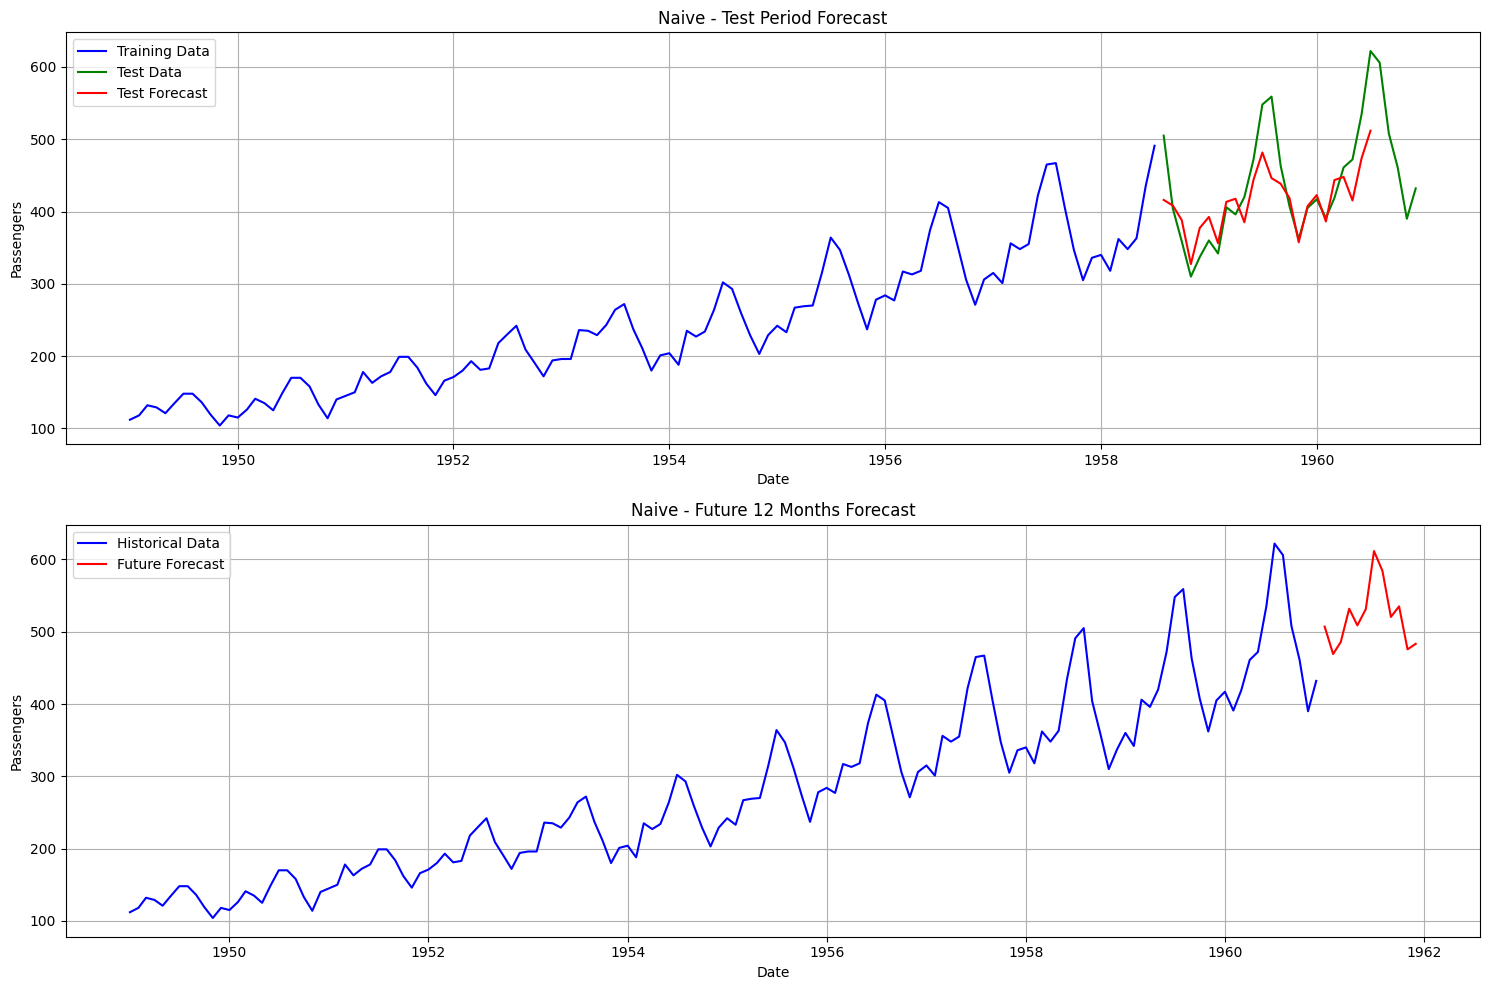


--------------------------------------------------
Testing exp_smoothing...
--------------------------------------------------
Fitting exp_smoothing on training data...
Fitting exp_smoothing forecaster with expanding cross-validation...
Fitting 4 folds for each of 144 candidates, totalling 576 fits


/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(


Generating test predictions for exp_smoothing...
Making predictions...
Test Predictions: 1958-08    473.699900
1958-09    406.813774
1958-10    349.039484
1958-11    308.211217
1958-12    341.984942
1959-01    349.605835
1959-02    332.055049
1959-03    382.880028
1959-04    374.655298
1959-05    393.092479
1959-06    468.239305
1959-07    509.186676
1959-08    503.710923
1959-09    434.347661
1959-10    374.712863
1959-11    332.901543
1959-12    367.227432
1960-01    375.095642
1960-02    356.495473
1960-03    408.530786
1960-04    400.219800
1960-05    419.774692
1960-06    497.621242
1960-07    539.506889
Freq: M, Name: Number of airline passengers, dtype: float64
Evaluating exp_smoothing on test set...

Test Performance Metrics:
------------------------------
RMSE: 35.0182
MAPE: 0.0626
MAE: 28.6662
MSE: 1226.2710
Refitting exp_smoothing on full dataset and generating future predictions...
Refitting exp_smoothing on full dataset with best parameters...


/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(


Generating future predictions for 12 periods...
Making predictions...
Test Predictions: 1958-08    473.699900
1958-09    406.813774
1958-10    349.039484
1958-11    308.211217
1958-12    341.984942
1959-01    349.605835
1959-02    332.055049
1959-03    382.880028
1959-04    374.655298
1959-05    393.092479
1959-06    468.239305
1959-07    509.186676
1959-08    503.710923
1959-09    434.347661
1959-10    374.712863
1959-11    332.901543
1959-12    367.227432
1960-01    375.095642
1960-02    356.495473
1960-03    408.530786
1960-04    400.219800
1960-05    419.774692
1960-06    497.621242
1960-07    539.506889
Freq: M, Name: Number of airline passengers, dtype: float64


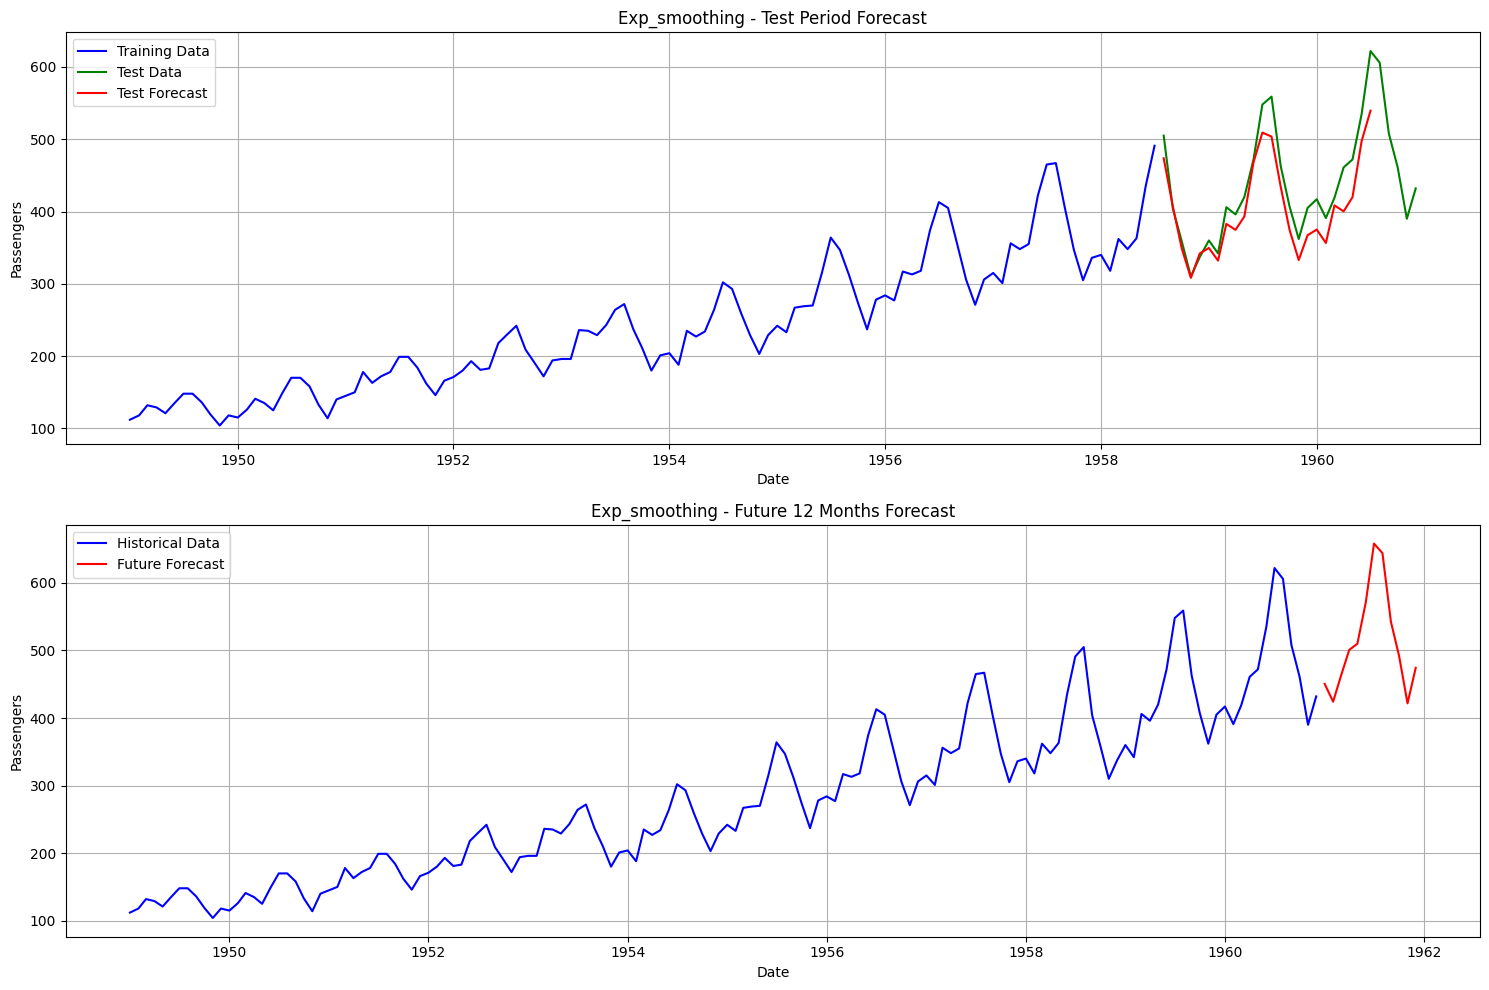


=== Algorithm Comparison ===
                    RMSE      MAPE        MAE
Algorithm                                    
naive          46.667008  0.072368  34.025865
exp_smoothing  35.018152  0.062558  28.666188

=== Best Algorithm per Metric ===
Best for RMSE: exp_smoothing (35.0182)
Best for MAPE: exp_smoothing (0.0626)
Best for MAE: exp_smoothing (28.6662)
Best for MSE: exp_smoothing (1226.2710)


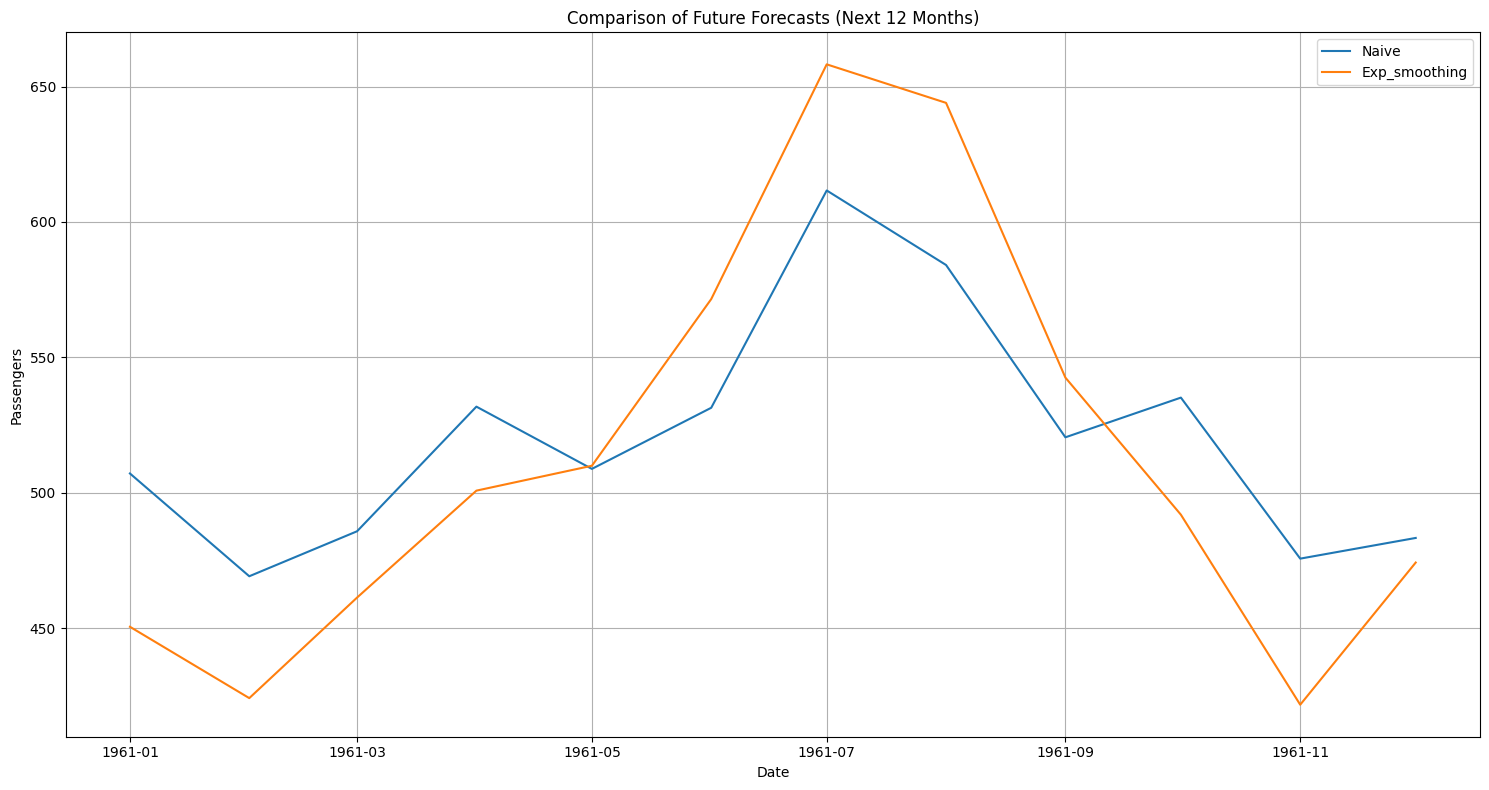


=== Summary ===
Total models evaluated: 2
Best algorithm by RMSE: exp_smoothing
All results stored in memory


In [ ]:
"""
Example using AdaptiveForecaster with the new refit_on_full_data method
"""
import warnings
import os
os.environ['PYTHONWARNINGS'] = 'ignore'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sktime.datasets import load_airline
#from adaptiveforecast.forecaster import AdaptiveForecaster


print("Loading airline passengers dataset...")
y = load_airline()

# Split data into train and test sets (last 24 months as test)
train_size = len(y) - 24
train, test = y.iloc[:train_size], y.iloc[train_size:]
print(f"Training set: {len(train)} observations ({train.index.min()} - {train.index.max()})")
print(f"Test set: {len(test)} observations ({test.index.min()} - {test.index.max()})")

# In-memory storage for results
results_storage = {
    "models": {},
    "test_predictions": {},
    "future_predictions": {}
}

# List of algorithms to compare
#algorithms = ['naive','stats_arima', 'exp_smoothing','ets','tbats','prophet']
algorithms = ['naive','exp_smoothing']
model_results = {}
comparison_data = []

for algo in algorithms:
    print(f"\n{'-'*50}")
    print(f"Testing {algo}...")
    print(f"{'-'*50}")
    
    try:
        # Create and fit forecaster on training data
        algo_forecaster = AdaptiveForecaster(
            algorithm=algo,
            seasonal_period=12,
            fh=len(test),
            cv_strategy='expanding',
            cv_initial_window=80,
            cv_step_length=3,
            metric='mape',
            n_jobs=1,
            verbose=1
        )
        
        # Split, fit, predict
        train_y, test_y = algo_forecaster.split_data(y)
        print(f"Fitting {algo} on training data...")
        algo_forecaster.fit(train_y)
        
        # Generate predictions for test period
        print(f"Generating test predictions for {algo}...")
        test_predictions = algo_forecaster.predict(fh=list(range(1, len(test) + 1)))
        print("Test Predictions:", test_predictions)
        # Evaluate with multiple metrics
        print(f"Evaluating {algo} on test set...")
        test_metrics = algo_forecaster.evaluate(metrics=['rmse', 'mape', 'mae', 'mse'])
        
        # Now use the new method to refit on full data and get future predictions
        print(f"Refitting {algo} on full dataset and generating future predictions...")
        future_horizon = 12
        future_predictions = algo_forecaster.forecast_future(y, future_horizon=future_horizon)
        
        # Store results
        result_id = f"{algo}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        
        # Store in the dictionaries
        results_storage["models"][result_id] = {
            "id": result_id,
            "algorithm": algo,
            "timestamp": datetime.now().isoformat(),
            "metrics": test_metrics,
            "best_params": algo_forecaster.best_params,
            "cv_score": float(algo_forecaster.best_score),
            "forecaster": algo_forecaster.grid_search.best_forecaster_
        }
        
        results_storage["test_predictions"][result_id] = test_predictions
        results_storage["future_predictions"][result_id] = future_predictions
        
        # Store in model_results for easier reference
        model_results[algo] = {
            "result_id": result_id,
            "forecaster": algo_forecaster,
            "test_predictions": test_predictions,
            "future_predictions": future_predictions,
            "metrics": test_metrics
        }
        
        # Add to comparison data
        comparison_data.append({
            'Algorithm': algo,
            'Result ID': result_id,
            'RMSE': test_metrics['rmse'],
            'MAPE': test_metrics['mape'],
            'MAE': test_metrics['mae'],
            'MSE': test_metrics['mse']
        })
        
        print("Test Predictions:", test_predictions)
        # Create visualization
        plt.figure(figsize=(15, 10))
        
        # Plot 1: Test period
        plt.subplot(2, 1, 1)
        plt.plot(train_y.index.to_timestamp(), train_y, 'b-', label='Training Data')
        plt.plot(test_y.index.to_timestamp(), test_y, 'g-', label='Test Data')
        plt.plot(test_predictions.index.to_timestamp(), test_predictions, 'r-', label=f'Test Forecast')
        plt.title(f'{algo.capitalize()} - Test Period Forecast')
        plt.xlabel('Date')
        plt.ylabel('Passengers')
        plt.legend()
        plt.grid(True)
        
        # Plot 2: Future predictions
        plt.subplot(2, 1, 2)
        plt.plot(y.index.to_timestamp(), y, 'b-', label='Historical Data')
        plt.plot(future_predictions.index.to_timestamp(), future_predictions, 'r-', label=f'Future Forecast')
        plt.title(f'{algo.capitalize()} - Future {future_horizon} Months Forecast')
        plt.xlabel('Date')
        plt.ylabel('Passengers')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error with {algo}: {e}")
        import traceback
        traceback.print_exc()

# Create comparison table
if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    
    print("\n=== Algorithm Comparison ===")
    print(comparison_df[['Algorithm', 'RMSE', 'MAPE', 'MAE']].set_index('Algorithm'))
    
    # Find best algorithm for each metric
    print("\n=== Best Algorithm per Metric ===")
    metrics = ['RMSE', 'MAPE', 'MAE', 'MSE']
    best_algorithms = {}
    
    for metric in metrics:
        best_algo_idx = comparison_df[metric].idxmin()
        best_algo = comparison_df.loc[best_algo_idx]
        best_algorithms[metric] = best_algo['Algorithm']
        print(f"Best for {metric}: {best_algo['Algorithm']} ({best_algo[metric]:.4f})")

# Create final comparison plot of future predictions
plt.figure(figsize=(15, 8))
for algo in model_results:
    future_pred = model_results[algo]["future_predictions"]
    plt.plot(future_pred.index.to_timestamp(), future_pred, '-', label=f'{algo.capitalize()}')

plt.title('Comparison of Future Forecasts (Next 12 Months)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


if comparison_data:
    best_metric = 'RMSE'  # Choose your preferred metric
    best_algo_name = best_algorithms[best_metric]
    best_result = model_results[best_algo_name]
    """
    print(f"\n=== Logging Best Model ({best_algo_name}) to MLflow ===")
    log_to_mlflow_sktime(
        forecaster=best_result["forecaster"],
        result_id=best_result["result_id"],
        metrics=best_result["metrics"]
    )
    """

print("\n=== Summary ===")
print(f"Total models evaluated: {len(results_storage['models'])}")
print(f"Best algorithm by RMSE: {best_algorithms.get('RMSE', 'N/A')}")
print(f"All results stored in memory")

In [36]:
#results_storage['test_predictions']
results_storage['future_predictions']

{'naive_20250311_195726': 1961-01    434.237762
 1961-02    436.475524
 1961-03    438.713287
 1961-04    440.951049
 1961-05    443.188811
 1961-06    445.426573
 1961-07    447.664336
 1961-08    449.902098
 1961-09    452.139860
 1961-10    454.377622
 1961-11    456.615385
 1961-12    458.853147
 Freq: M, Name: Number of airline passengers, dtype: float64,
 'stats_arima_20250311_195916': 1961-01    462.643741
 1961-02    492.150462
 1961-03    522.320688
 1961-04    545.543306
 1961-05    557.307858
 1961-06    556.946973
 1961-07    547.211519
 1961-08    532.978982
 1961-09    519.584896
 1961-10    511.292748
 1961-11    510.298523
 1961-12    516.457385
 Freq: M, Name: Number of airline passengers, dtype: float64,
 'exp_smoothing_20250311_200219': 1961-01    433.864374
 1961-02    435.926623
 1961-03    437.988872
 1961-04    440.051121
 1961-05    442.113370
 1961-06    444.175619
 1961-07    446.237868
 1961-08    448.300117
 1961-09    450.362366
 1961-10    452.424616
 1961

naive_20250311_195726
stats_arima_20250311_195916
exp_smoothing_20250311_200219


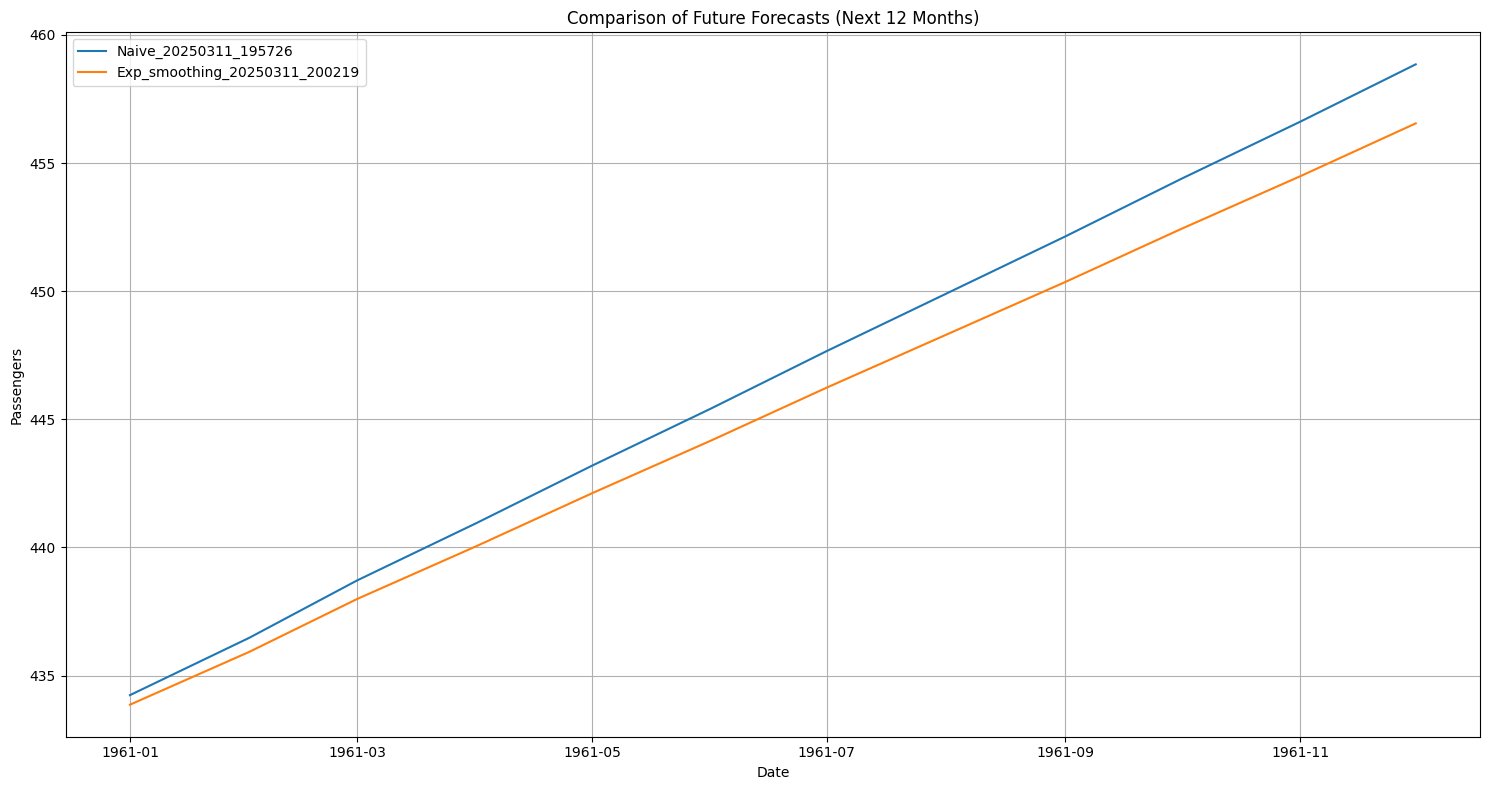

In [41]:
plt.figure(figsize=(15, 8))
for algo in results_storage['future_predictions']:
    print(algo)
    future_pred = results_storage["future_predictions"][algo]
    # Convert Period index to datetime for plotting
    if 'naive' in algo or 'exp' in algo:
        plt.plot(future_pred.index.to_timestamp(), future_pred, '-', label=f'{algo.capitalize()}')
    # Alternative: plt.plot(pd.to_datetime(future_pred.index.astype(str)), future_pred, '-', label=f'{algo.capitalize()}')

# ... existing code ...
plt.title('Comparison of Future Forecasts (Next 12 Months)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
model_results['naive']['forecaster'].forecaster.permuted

Permute(estimator=TransformedTargetForecaster(steps=[('detrender',
                                                      OptionalPassthrough(transformer=Detrender())),
                                                     ('deseasonalizer',
                                                      OptionalPassthrough(transformer=Deseasonalizer(sp=12))),
                                                     ('scaler',
                                                      OptionalPassthrough(transformer=TabularToSeriesAdaptor(transformer=RobustScaler()))),
                                                     ('forecaster',
                                                      NaiveForecaster(sp=12))]))